<a href="https://colab.research.google.com/github/nanaaries313/Portfolio/blob/main/Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Week 5: Independent test set or resampling? Parameter tuning.**

Vote Data case Study

Start by loading the relative libraries.

In [12]:
pkgs <- c("rpart", "rpart.plot", "e1071", "caret", "ggplot2")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

In [13]:
library(rpart)
library(rpart.plot)
library(e1071)
library(caret)
library(ggplot2)

Loading required package: ggplot2


Attaching package: ‘ggplot2’


The following object is masked from ‘package:e1071’:

    element


Loading required package: lattice



## **Monday Material: Titanic Data**

In [14]:
pkgs <- c("titanic")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [15]:
library(titanic)
View(titanic_train)

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,,S
6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.0750,,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S


Want to predict "Survived"


Let's try to build a tree and check the training error

In [16]:
titanic_train$Survived = factor(titanic_train$Survived)
tree.model = rpart(Survived~., data=titanic_train)
table(predict(tree.model,titanic_train,type="class"),
      titanic_train$Survived)

   
      0   1
  0 549   0
  1   0 342

It's pretty easy to predict survival based on the name!

In [17]:
str(titanic_train)

'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : Factor w/ 2 levels "0","1": 1 2 2 2 1 1 1 1 2 2 ...
 $ Pclass     : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : chr  "Braund, Mr. Owen Harris" "Cumings, Mrs. John Bradley (Florence Briggs Thayer)" "Heikkinen, Miss. Laina" "Futrelle, Mrs. Jacques Heath (Lily May Peel)" ...
 $ Sex        : chr  "male" "female" "female" "female" ...
 $ Age        : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : chr  "A/5 21171" "PC 17599" "STON/O2. 3101282" "113803" ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : chr  "" "C85" "" "C123" ...
 $ Embarked   : chr  "S" "C" "S" "S" ...


What should we do with this data?

We cannot use any variables as predictors (independent variables) if they are unique identifiers. Lets specify the set of predictors and try again.

In [18]:
predictors = c("Pclass","Sex","Age","SibSp",
               "Parch","Fare","Embarked")

 We can specify the formula as a string using the paste() function

In [19]:
paste("Survived~",paste(predictors, collapse= "+"))

[1] "Survived~ Pclass+Sex+Age+SibSp+Parch+Fare+Embarked"

Paste() helps join strings together

 And then coerce this string into a formula

In [20]:
as.formula(paste("Survived~",paste(predictors, collapse= "+")))

Survived ~ Pclass + Sex + Age + SibSp + Parch + Fare + Embarked

 Now we'll do this in the rpart() function (we could also save the formula in an object).

In [21]:
tree.model = rpart(as.formula(paste("Survived~",
                                    paste(predictors, collapse= "+"))),
                   data=titanic_train)

 Check the training data confusion matrix and plot the tree

   
      0   1
  0 521 115
  1  28 227

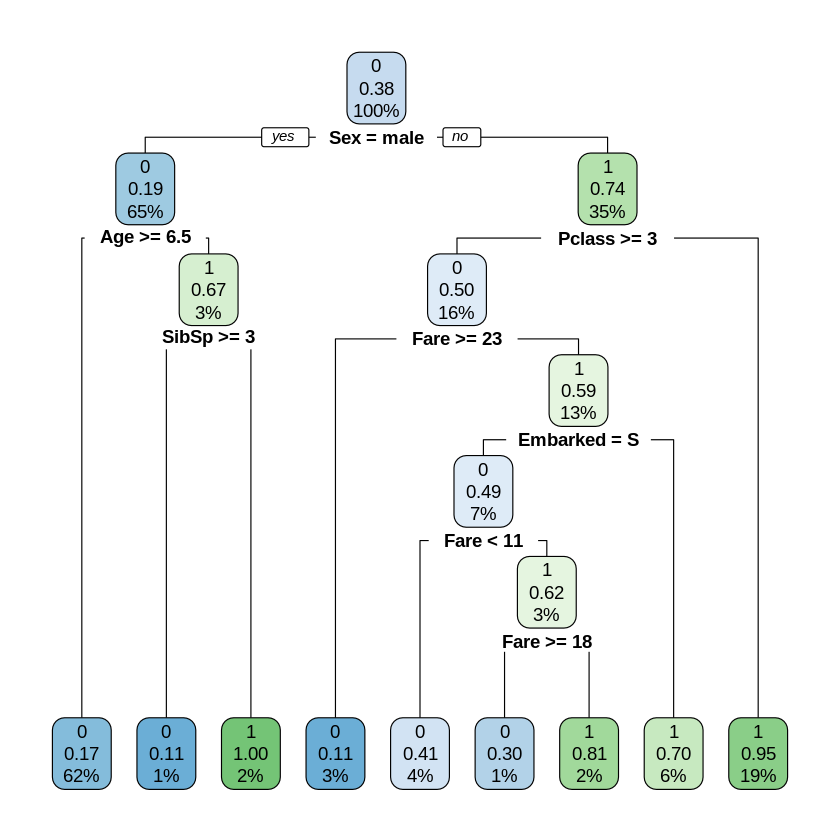

In [22]:
table(predict(tree.model,titanic_train,type="class"),
      titanic_train$Survived)
rpart.plot(tree.model)

This is now a meaningful tree!

Let's tune the model using the train() function

Warning message:
“predictions failed for Resample02: cp=0.001 Error in model.frame.default(Terms, newdata, na.action = na.action, xlev = attr(object,  : 
  factor Embarked has new levels 
”
Warning message:
“predictions failed for Resample05: cp=0.001 Error in model.frame.default(Terms, newdata, na.action = na.action, xlev = attr(object,  : 
  factor Embarked has new levels 
”
Warning message:
“predictions failed for Resample07: cp=0.001 Error in model.frame.default(Terms, newdata, na.action = na.action, xlev = attr(object,  : 
  factor Embarked has new levels 
”
Warning message:
“predictions failed for Resample14: cp=0.001 Error in model.frame.default(Terms, newdata, na.action = na.action, xlev = attr(object,  : 
  factor Embarked has new levels 
”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


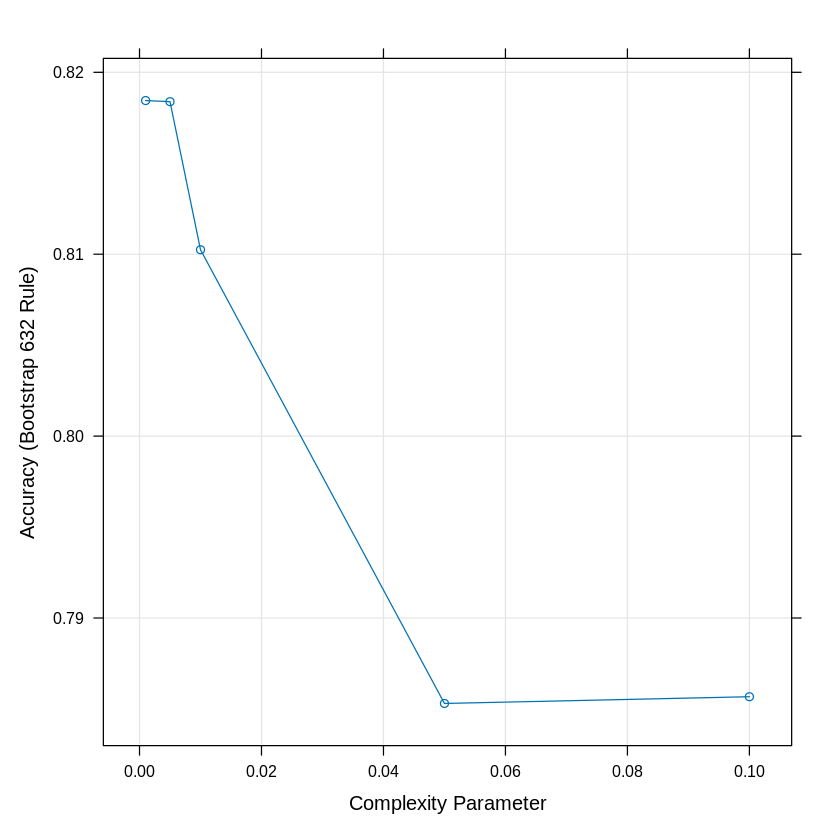

In [23]:
tuned.tree= train(titanic_train[,predictors], titanic_train$Survived,
                  method="rpart",
                  trControl = trainControl(method="boot632"),
                  tuneGrid = expand.grid(cp = c(0.001, 0.005,
                                                0.01, 0.05, 0.1)))
plot(tuned.tree)

Again, low cp values (no or little pruning) looks good, but we've seen before that this could be because of a bias in the 0.632 bootstrap.

Lets try 10-fold cross-validation instead.

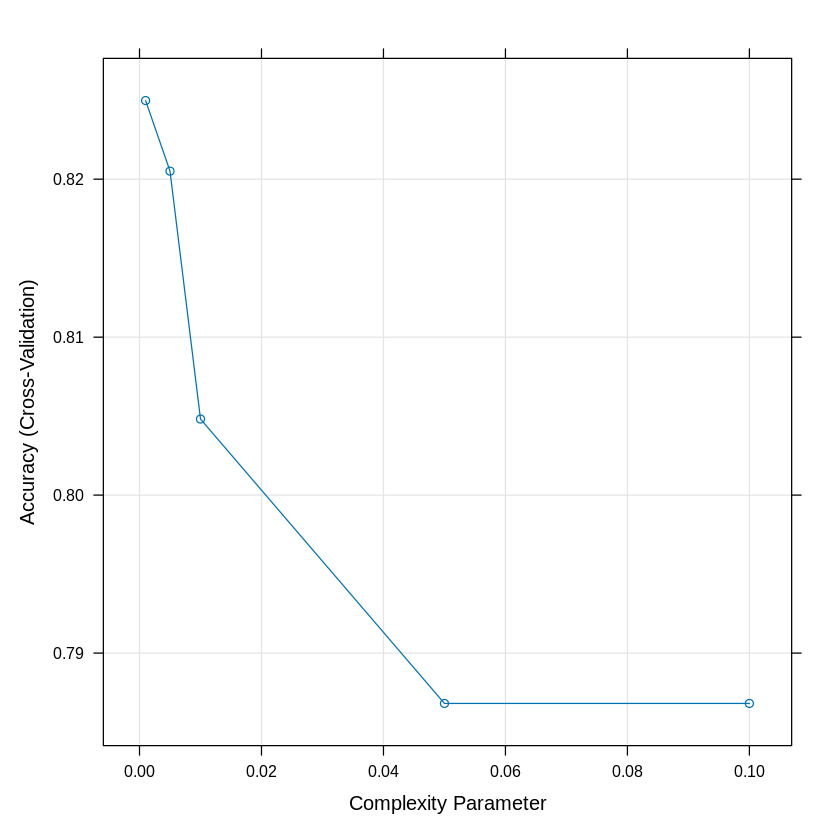

In [24]:
tuned.tree= train(titanic_train[,predictors], titanic_train$Survived,
                  method="rpart",
                  trControl = trainControl(method="cv"),
                  tuneGrid = expand.grid(cp = c(0.001, 0.005,
                                                0.01, 0.05, 0.1)))
plot(tuned.tree)

I very much like the fact that both methods are giving be very similar results!

10-fold cross-validation probably has less bias than the 0.632-bootstrap,at least for small cp values but it also has higher variance.

The LOOCV has the least bias (but potentially even higher variance).

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


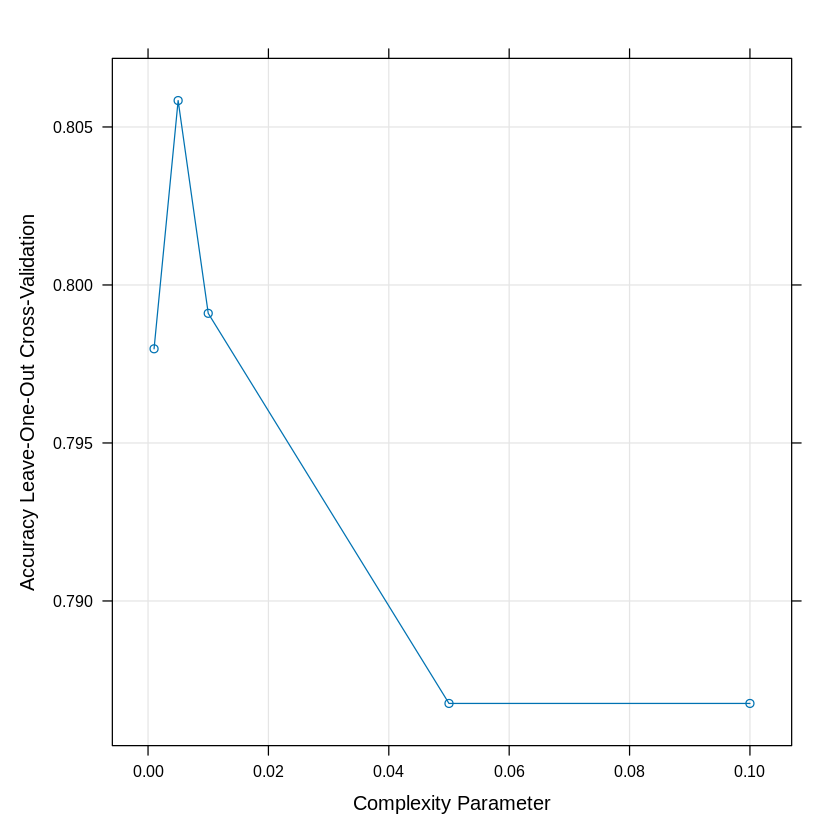

In [25]:
tuned.tree= train(titanic_train[,predictors], titanic_train$Survived,
                  method="rpart",
                  trControl = trainControl(method="loocv"),
                  tuneGrid = expand.grid(cp = c(0.001, 0.005,
                                                0.01, 0.05, 0.1)))
plot(tuned.tree)

Everything is pointing toward an optimal value of cp = 0.005.

 Is cp = 0.005 different from the default cp = 0.01?

   
      0   1
  0 515  91
  1  34 251

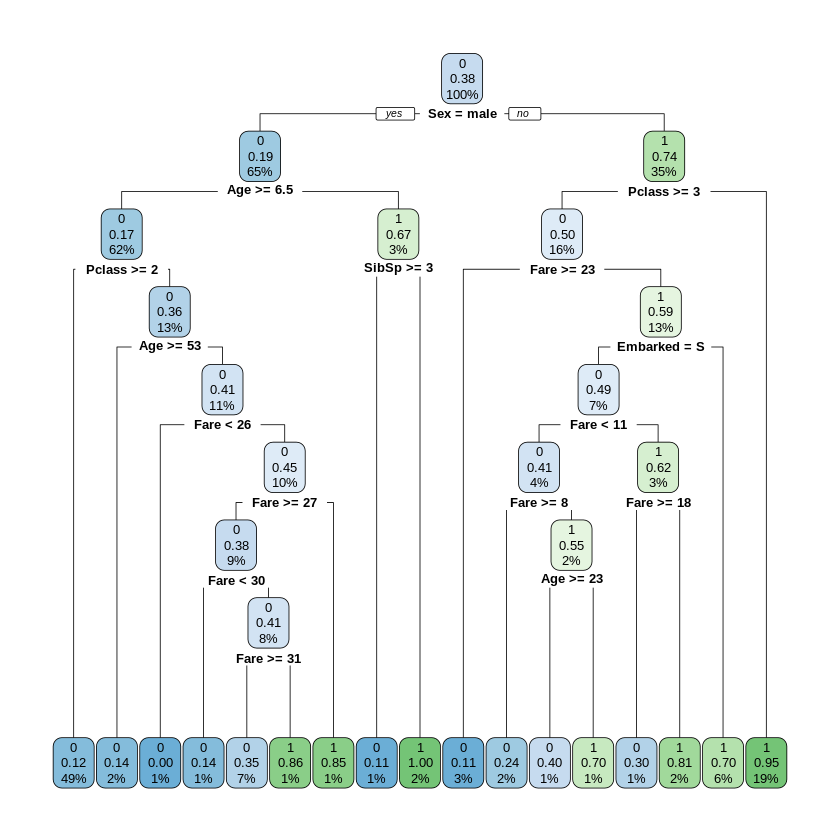

In [27]:
tree.model.opt = rpart(as.formula(paste("Survived~",
                                        paste(predictors, collapse= "+"))),
                       data=titanic_train,
                       cp = 0.005)
table(predict(tree.model.opt,titanic_train,type="class"),
      titanic_train$Survived)
rpart.plot(tree.model.opt)


Remember

   
      0   1
  0 521 115
  1  28 227

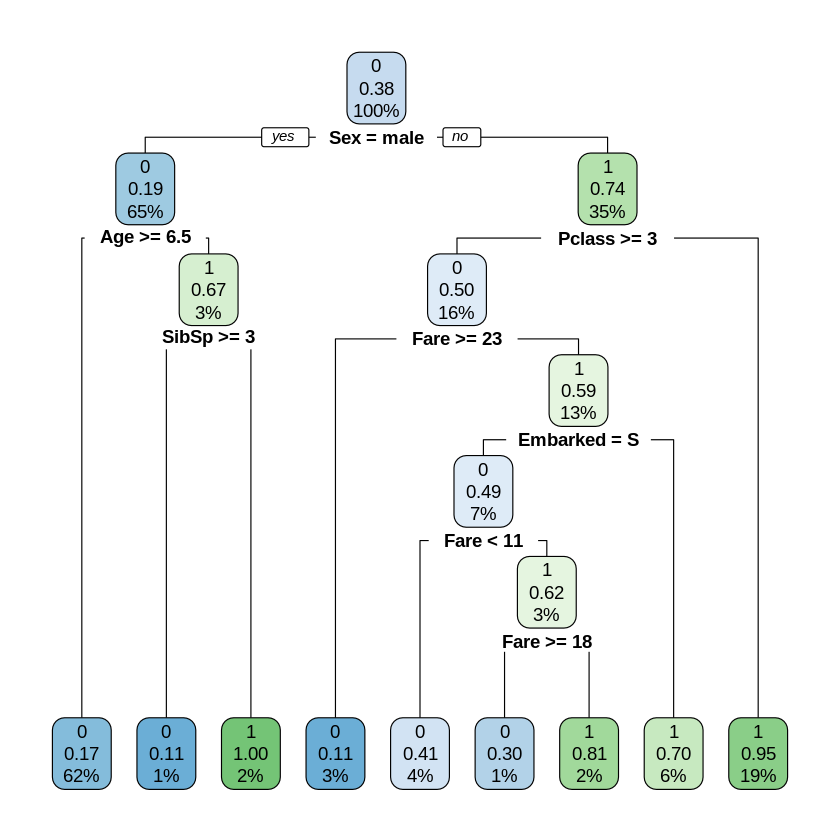

In [28]:
table(predict(tree.model,titanic_train,type="class"),
      titanic_train$Survived)
rpart.plot(tree.model)

So yes, with parameter cp = 0.005 the tree fits closer to the data (a more complex tree that has lower training error). And all of the potential upside for tuning the tree comes from misclassifying fewer "yes" values as "no".

## **Vote Data**

The vote data describes how member of the US House of Representitives voted on 16 bills in 1984, along with their party affiliation. You will use this data in Homework 3 for a different purpose, but here we are going to treat it as a prediction problem where we want to predict party affiliation (democrat or republican).

In [58]:
vote = read.csv("vote.csv")
str(vote)

'data.frame':	435 obs. of  17 variables:
 $ handicapped.infants                   : chr  "n" "n" "?" "n" ...
 $ water.project.cost.sharing            : chr  "y" "y" "y" "y" ...
 $ adoption.of.the.budget.resolution     : chr  "n" "n" "y" "y" ...
 $ physician.fee.freeze                  : chr  "y" "y" "?" "n" ...
 $ el.salvador.aid                       : chr  "y" "y" "y" "?" ...
 $ religious.groups.in.schools           : chr  "y" "y" "y" "y" ...
 $ anti.satellite.test.ban               : chr  "n" "n" "n" "n" ...
 $ aid.to.nicaraguan.contras             : chr  "n" "n" "n" "n" ...
 $ mx.missile                            : chr  "n" "n" "n" "n" ...
 $ immigration                           : chr  "y" "n" "n" "n" ...
 $ synfuels.corporation.cutback          : chr  "?" "n" "y" "y" ...
 $ education.spending                    : chr  "y" "y" "n" "n" ...
 $ superfund.right.to.sue                : chr  "y" "y" "y" "y" ...
 $ crime                                 : chr  "y" "y" "y" "n" ...
 $ duty

In [59]:
View(vote)

handicapped.infants,water.project.cost.sharing,adoption.of.the.budget.resolution,physician.fee.freeze,el.salvador.aid,religious.groups.in.schools,anti.satellite.test.ban,aid.to.nicaraguan.contras,mx.missile,immigration,synfuels.corporation.cutback,education.spending,superfund.right.to.sue,crime,duty.free.exports,export.administration.act.south.africa,Class
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y,republican
n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?,republican
?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n,democrat
n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y,democrat
y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y,democrat
n,y,y,n,y,y,n,n,n,n,n,n,y,y,y,y,democrat
n,y,n,y,y,y,n,n,n,n,n,n,?,y,y,y,democrat
n,y,n,y,y,y,n,n,n,n,n,n,y,y,?,y,republican
n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,y,republican


How should we deal with the "?" values?

We could either say that a ? is a meaningful value; that is, a non-vote is meaningful, or we can treat them as missing values.

A missing value in R should be denoted NA (or Not Available). We are going to treat the ? values as missing for now.

In [60]:
vote[vote == "?"] = NA

In [61]:
str(vote)

'data.frame':	435 obs. of  17 variables:
 $ handicapped.infants                   : chr  "n" "n" NA "n" ...
 $ water.project.cost.sharing            : chr  "y" "y" "y" "y" ...
 $ adoption.of.the.budget.resolution     : chr  "n" "n" "y" "y" ...
 $ physician.fee.freeze                  : chr  "y" "y" NA "n" ...
 $ el.salvador.aid                       : chr  "y" "y" "y" NA ...
 $ religious.groups.in.schools           : chr  "y" "y" "y" "y" ...
 $ anti.satellite.test.ban               : chr  "n" "n" "n" "n" ...
 $ aid.to.nicaraguan.contras             : chr  "n" "n" "n" "n" ...
 $ mx.missile                            : chr  "n" "n" "n" "n" ...
 $ immigration                           : chr  "y" "n" "n" "n" ...
 $ synfuels.corporation.cutback          : chr  NA "n" "y" "y" ...
 $ education.spending                    : chr  "y" "y" "n" "n" ...
 $ superfund.right.to.sue                : chr  "y" "y" "y" "y" ...
 $ crime                                 : chr  "y" "y" "y" "n" ...
 $ duty.fre

We can then drop those unused "?" factor levels using the droplevels() function. To remove any unused factor levels from vote

In [62]:
vote = droplevels(vote)
str(vote)

'data.frame':	435 obs. of  17 variables:
 $ handicapped.infants                   : chr  "n" "n" NA "n" ...
 $ water.project.cost.sharing            : chr  "y" "y" "y" "y" ...
 $ adoption.of.the.budget.resolution     : chr  "n" "n" "y" "y" ...
 $ physician.fee.freeze                  : chr  "y" "y" NA "n" ...
 $ el.salvador.aid                       : chr  "y" "y" "y" NA ...
 $ religious.groups.in.schools           : chr  "y" "y" "y" "y" ...
 $ anti.satellite.test.ban               : chr  "n" "n" "n" "n" ...
 $ aid.to.nicaraguan.contras             : chr  "n" "n" "n" "n" ...
 $ mx.missile                            : chr  "n" "n" "n" "n" ...
 $ immigration                           : chr  "y" "n" "n" "n" ...
 $ synfuels.corporation.cutback          : chr  NA "n" "y" "y" ...
 $ education.spending                    : chr  "y" "y" "n" "n" ...
 $ superfund.right.to.sue                : chr  "y" "y" "y" "y" ...
 $ crime                                 : chr  "y" "y" "y" "n" ...
 $ duty.fre

 We now have a cleaned-up data set. There is almost always some type of cleaning up to do with your data. Usually, much more than what we did here.

In [35]:
summary(vote)

 handicapped.infants water.project.cost.sharing
 Length:435          Length:435                
 Class :character    Class :character          
 Mode  :character    Mode  :character          
 adoption.of.the.budget.resolution physician.fee.freeze el.salvador.aid   
 Length:435                        Length:435           Length:435        
 Class :character                  Class :character     Class :character  
 Mode  :character                  Mode  :character     Mode  :character  
 religious.groups.in.schools anti.satellite.test.ban aid.to.nicaraguan.contras
 Length:435                  Length:435              Length:435               
 Class :character            Class :character        Class :character         
 Mode  :character            Mode  :character        Mode  :character         
  mx.missile        immigration        synfuels.corporation.cutback
 Length:435         Length:435         Length:435                  
 Class :character   Class :character   Class :character 

As always we have two decisions: a) which model to use (NB, DT, KNN), and b) how to evaluate the error of the model? These decision are interconnected; that is, the answer to b) depends on the answer to a), so we try to answer them simultaneously.

## **Decision Trees**

First, I'm going to decide if I want to split the data into training and test data or train on all the data and then use resampling to evaluate the error.

In [36]:
vote$Class <- factor(vote$Class, levels = c("democrat", "republican"))
DT.accuracy = NULL
for(i in 1:50) {
  # createDataPartition() is a function in caret that we can use instead of
  # the builts-in sample() function. It has more options that sample().
  trainIndex = createDataPartition(vote$Class,
                                   p=.67,       # Proportion of data
                                   list=FALSE,  # Output format, False=matrix
                                   times=1)     # Number of subsets
                                                #create only one set of
                                                #training and testing
  voteTrain = vote[trainIndex,]
  voteTest = vote[-trainIndex,]
  DTmodel = rpart(Class ~ . ,
                  data=voteTrain)
  prediction = predict(DTmodel,voteTest,type="class")
  DT.accuracy[i] = confusionMatrix(prediction,voteTest$Class)$overall[1]
}
DT.accuracy
sqrt(var(DT.accuracy))

[1] 0.9300699 0.9580420 0.9790210 0.9510490 0.9300699 0.9650350 0.9650350
 [8] 0.9510490 0.9510490 0.9510490 0.9510490 0.9580420 0.9720280 0.9720280
[15] 0.9440559 0.9720280 0.9510490 0.9580420 0.9510490 0.9510490 0.9370629
[22] 0.9370629 0.9650350 0.9580420 0.9440559 0.9580420 0.9510490 0.9580420
[29] 0.9370629 0.9580420 0.9300699 0.9510490 0.9580420 0.9370629 0.9580420
[36] 0.9370629 0.9650350 0.9510490 0.9440559 0.9370629 0.9510490 0.9650350
[43] 0.9650350 0.9510490 0.9370629 0.9580420 0.9370629 0.9790210 0.9090909
[50] 0.9580420

[1] 0.01381658

The variance is quite low, so I feel that reserving a test dataset is ok.

 There is no fixed threshold for this - its a judgement call.

Split the data into a test and training dataset (2/3 train, 1/3 test)

In [37]:
set.seed(1234)
trainIndex = createDataPartition(vote$Class,
                                 p=.67,
                                 list=FALSE,
                                 times=1)
voteTrain = vote[trainIndex,]
voteTest = vote[-trainIndex,]

Build and plot a decision tree model

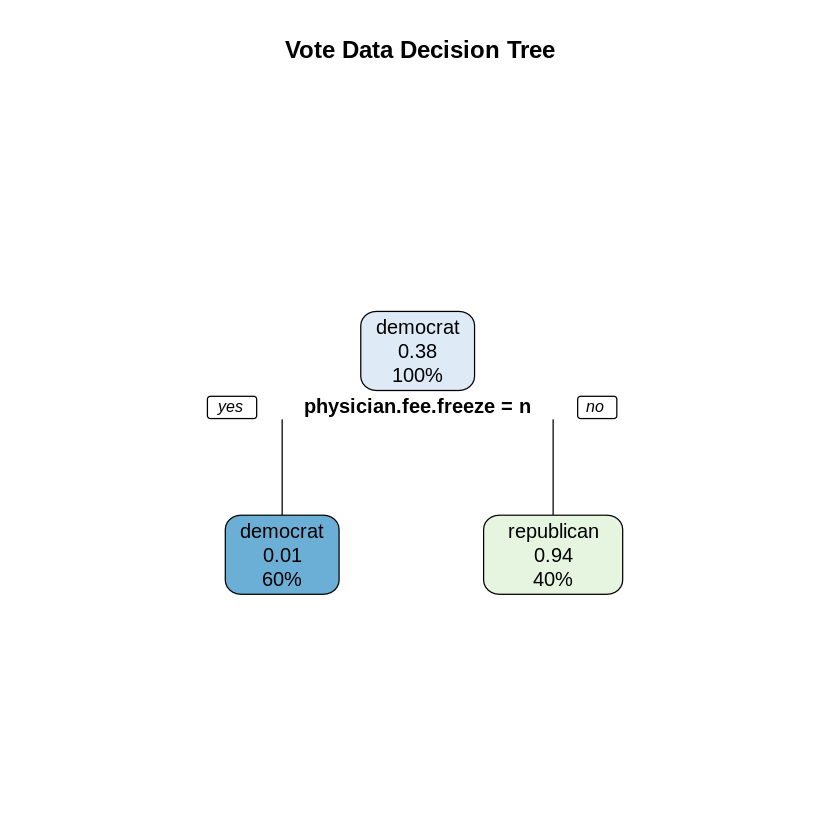

In [38]:
DTmodel = rpart(Class ~ . , data=voteTrain)
rpart.plot(DTmodel,
           main="Vote Data Decision Tree")

In [40]:
# Apply the DT to the test data
prediction = predict(DTmodel,voteTest,type="class")
# Create a confusion matrix to evaluate the quality of the model
CM.default = confusionMatrix(prediction,voteTest$Class) # Could use table()

CM.train = confusionMatrix(predict(DTmodel,voteTrain,type="class"),
                                   voteTrain$Class)
CM.default
CM.train

Confusion Matrix and Statistics

            Reference
Prediction   democrat republican
  democrat         80          2
  republican        8         53
                                         
               Accuracy : 0.9301         
                 95% CI : (0.8752, 0.966)
    No Information Rate : 0.6154         
    P-Value [Acc > NIR] : <2e-16         
                                         
                  Kappa : 0.8552         
                                         
 Mcnemar's Test P-Value : 0.1138         
                                         
            Sensitivity : 0.9091         
            Specificity : 0.9636         
         Pos Pred Value : 0.9756         
         Neg Pred Value : 0.8689         
             Prevalence : 0.6154         
         Detection Rate : 0.5594         
   Detection Prevalence : 0.5734         
      Balanced Accuracy : 0.9364         
                                         
       'Positive' Class : democrat       
      

Confusion Matrix and Statistics

            Reference
Prediction   democrat republican
  democrat        172          3
  republican        7        110
                                          
               Accuracy : 0.9658          
                 95% CI : (0.9379, 0.9835)
    No Information Rate : 0.613           
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.9283          
                                          
 Mcnemar's Test P-Value : 0.3428          
                                          
            Sensitivity : 0.9609          
            Specificity : 0.9735          
         Pos Pred Value : 0.9829          
         Neg Pred Value : 0.9402          
             Prevalence : 0.6130          
         Detection Rate : 0.5890          
   Detection Prevalence : 0.5993          
      Balanced Accuracy : 0.9672          
                                          
       'Positive' Class : dem

What do we observe from the confusion matrix? The training accuracy is higher than the test accuracy (overfitting). It is indicated that the model has memorized the traing data too well and will not generalize effectively to new data

Is this the best tree? Let's try to tune the parameter(s). The main parameter is cp = complexity parameters. What does it do?

The default cp parameter is a good starting point and we can obtain that as one of the control parameters used by model if we don't remember.

In [41]:
DTmodel$control$cp

[1] 0.01

The default value is cp = 0.01. Let's try both smaller and bigger values (e.g., two smaller and two bigger).

CART 

292 samples
 16 predictor
  2 classes: 'democrat', 'republican' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 292, 292, 292, 292, 292, 292, ... 
Resampling results across tuning parameters:

  cp     Accuracy   Kappa    
  0.001  0.9625537  0.9212519
  0.005  0.9634850  0.9234697
  0.010  0.9634850  0.9234697
  0.050  0.9658188  0.9284609
  0.100  0.9658188  0.9284609

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.1.

CART 

292 samples
 16 predictor
  2 classes: 'democrat', 'republican' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 292, 292, 292, 292, 292, 292, ... 
Resampling results across tuning parameters:

  cp     Accuracy   Kappa    
  0.001  0.9645361  0.9251700
  0.005  0.9645361  0.9251700
  0.010  0.9661873  0.9288116
  0.050  0.9666348  0.9298019
  0.100  0.9666348  0.9298019
  0.150  0.9666348  0.9298019
  0.200  0.9666348  0.9298019

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.2.

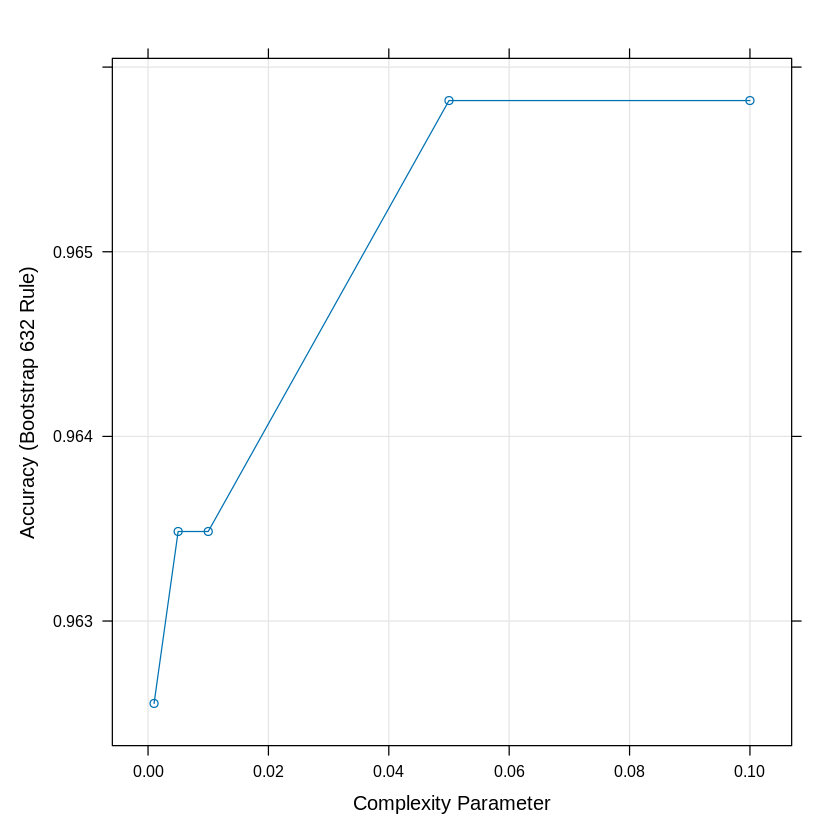

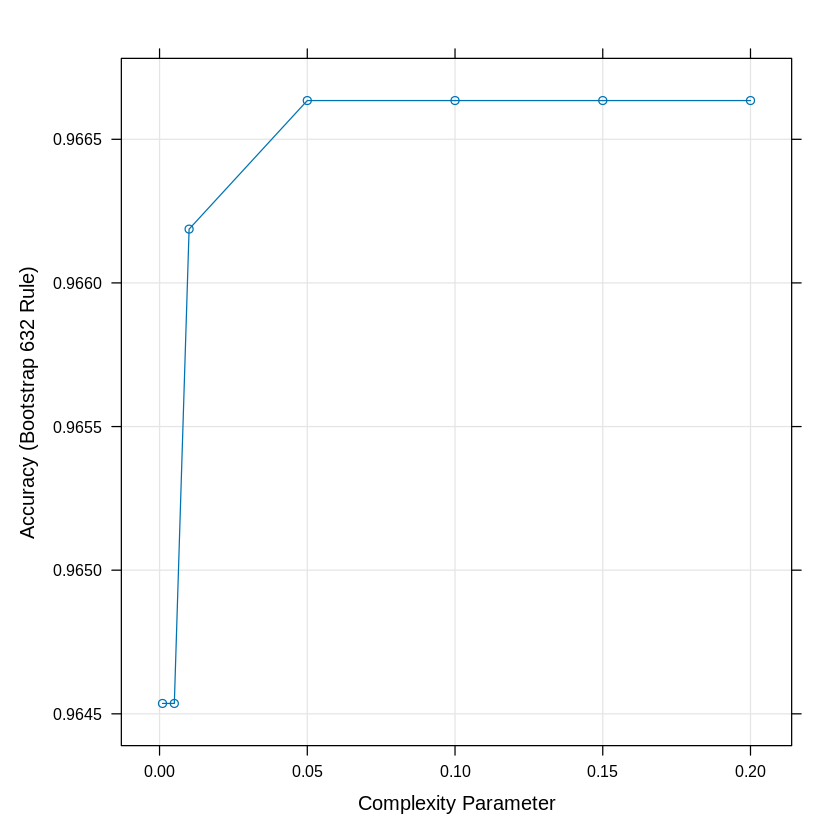

In [42]:

DTmodel.tuned = train(voteTrain[,1:16], voteTrain$Class,
                 method="rpart",
                 trControl = trainControl(method="boot632"),
                 tuneGrid = expand.grid(cp = c(0.001, 0.005, 0.01,
                                               0.05, 0.1)))
DTmodel.tuned
plot(DTmodel.tuned)

# Based on these results, maybe we want to increase cp even more?
DTmodel.tuned.2 = train(voteTrain[,1:16], voteTrain$Class,
                      method="rpart",
                      trControl = trainControl(method="boot632"),
                      tuneGrid = expand.grid(cp = c(0.001, 0.005,
                                                    0.01, 0.05, 0.1,
                                                    0.15, 0.2)))
DTmodel.tuned.2
plot(DTmodel.tuned.2)

Notice how the accuracy values in the figure change. Is this normal?

When I run it several times, higher values of cp are always better and it levels out at 0.10 at the latest.

Is a tree with cp = 0.10 really better than a tree trained with cp = 0.01?

Build and plot a decision tree model using the optimal parameter

Confusion Matrix and Statistics

            Reference
Prediction   democrat republican
  democrat         80          2
  republican        8         53
                                         
               Accuracy : 0.9301         
                 95% CI : (0.8752, 0.966)
    No Information Rate : 0.6154         
    P-Value [Acc > NIR] : <2e-16         
                                         
                  Kappa : 0.8552         
                                         
 Mcnemar's Test P-Value : 0.1138         
                                         
            Sensitivity : 0.9091         
            Specificity : 0.9636         
         Pos Pred Value : 0.9756         
         Neg Pred Value : 0.8689         
             Prevalence : 0.6154         
         Detection Rate : 0.5594         
   Detection Prevalence : 0.5734         
      Balanced Accuracy : 0.9364         
                                         
       'Positive' Class : democrat       
      

Accuracy 
0.9300699

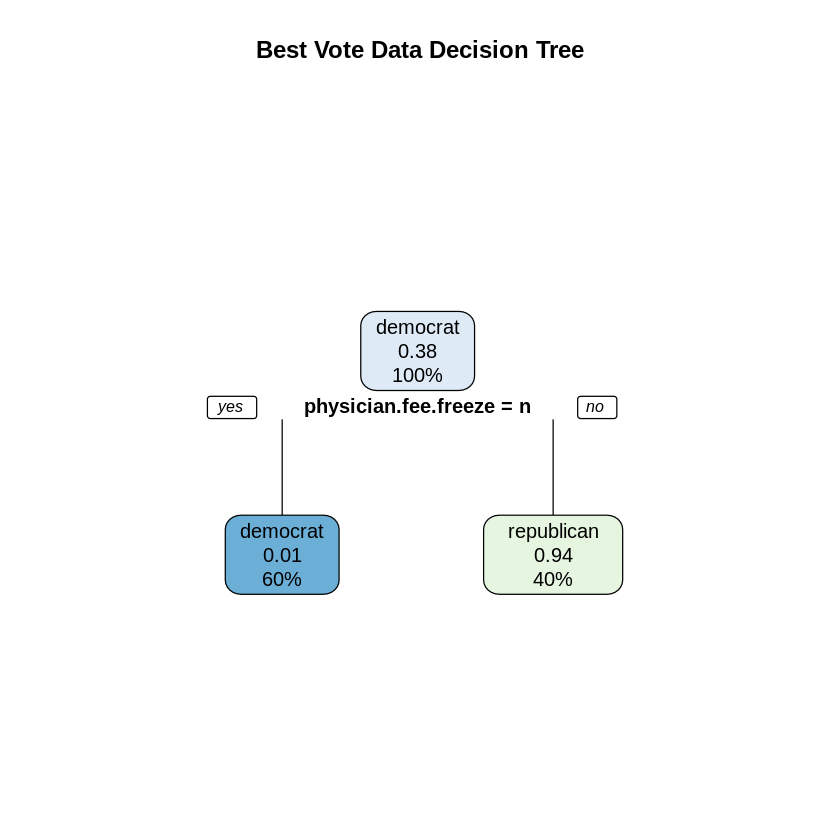

In [47]:
set.seed(1234)
trainIndex = createDataPartition(vote$Class,p=.67,list=FALSE,times=1)
voteTrain = vote[trainIndex,]
voteTest = vote[-trainIndex,]
DTmodel.best = rpart(Class ~ . , data=voteTrain,
                    control = rpart.control(cp = 0.1))
rpart.plot(DTmodel.best, main="Best Vote Data Decision Tree")
# Apply the DT to the test data
prediction = predict(DTmodel.best,voteTest,type="class")
# Create a confusion matrix to evaluate the quality of the model
CM.best = confusionMatrix(prediction,voteTest$Class)
CM.best

# Actually, it built exactly the same tree! And the unbiased estimate of
# the accuracy is
CM.best$overall[1]

Does this make sense?
a) Why did the tuning think that a different/better tree could be trained?
b) Why is the independent test data estimate = 0.937 smaller than the CV estimate ~ 0.96, even though the CV estimate is supposed to be conservative?

a) When tuning each model is built on resamples of 292 data points, with each resample including an average of 0.632*292 = 184.5 data points. While we may get consistent results when we resample the original 435 data points (low variance), that may no longer be true for the smaller split data. High accuracy when we used cv, but there are high variance between folds, so when we did it with independent testing. Nothing changes

b) This is normal because of the variance of the error estimates. Remember our earlier results for using an independent test dataset:
min(DT.accuracy)
max(DT.accuracy)
mean(DT.accuracy)

These differences are easily explained by the variance (even though the variance is relatively low here).

In [49]:
min(DT.accuracy)
max(DT.accuracy)
mean(DT.accuracy)

[1] 0.9090909

[1] 0.979021

[1] 0.9518881

## **Naive Bayes**

In [51]:
# Now repeat for Naive Bayes
NB.accuracy = NULL
for(i in 1:50) {
  trainIndex = createDataPartition(vote$Class,p=.67,list=FALSE,times=1)
  voteTrain = vote[trainIndex,]
  voteTest = vote[-trainIndex,]
  NBmodel = naiveBayes(Class ~ . , data=voteTrain)
  prediction = predict(NBmodel,voteTest,type="class")
  NB.accuracy[i] = confusionMatrix(prediction,voteTest$Class)$overall[1]
}
NB.accuracy
mean(NB.accuracy)

[1] 0.8741259 0.8951049 0.9090909 0.8951049 0.8741259 0.8671329 0.8951049
 [8] 0.8461538 0.9370629 0.9370629 0.9440559 0.9090909 0.9230769 0.9300699
[15] 0.8671329 0.8881119 0.9020979 0.9020979 0.8671329 0.9300699 0.8881119
[22] 0.8531469 0.9090909 0.8811189 0.9090909 0.9230769 0.9370629 0.9020979
[29] 0.9160839 0.8671329 0.9230769 0.9020979 0.9020979 0.9300699 0.9020979
[36] 0.9300699 0.8811189 0.9090909 0.8951049 0.9230769 0.9160839 0.8811189
[43] 0.9230769 0.9090909 0.9230769 0.8951049 0.9160839 0.9230769 0.8881119
[50] 0.8881119

[1] 0.9027972

On the average the accuracy of Naive Bayes is worse than decision trees for this data:
mean(NB.accuracy)
mean(DT.accuracy)

Is this expected? Does it make sense for this data?

Lets look at the variance for both models:

In [52]:
sqrt(var(NB.accuracy))
sqrt(var(DT.accuracy))

[1] 0.02339668

[1] 0.01381658

The variance is higher than before, so there is more reason to use resampling for the final evaluation, that is, to train on all the data and then use a resampling procedure to estimate the accuracy/ error of the model learned from all the data.

In [55]:
prediction = predict(NBmodel,voteTest,type="class")
# Create a confusion matrix to evaluate the quality of the model
CM.NB = confusionMatrix(prediction,voteTest$Class)
CM.NB

Confusion Matrix and Statistics

            Reference
Prediction   democrat republican
  democrat         76          4
  republican       12         51
                                          
               Accuracy : 0.8881          
                 95% CI : (0.8247, 0.9347)
    No Information Rate : 0.6154          
    P-Value [Acc > NIR] : 2.908e-13       
                                          
                  Kappa : 0.7699          
                                          
 Mcnemar's Test P-Value : 0.08012         
                                          
            Sensitivity : 0.8636          
            Specificity : 0.9273          
         Pos Pred Value : 0.9500          
         Neg Pred Value : 0.8095          
             Prevalence : 0.6154          
         Detection Rate : 0.5315          
   Detection Prevalence : 0.5594          
      Balanced Accuracy : 0.8955          
                                          
       'Positive' Class : dem

## **KNN**

Before using knn, we may also be interested in converting the "n" and "y" factor levels into numeric values. We can do that as follows. If the factor levels are numbers then we can coerce it into numbers using the as.numeric() function.

In [ ]:
#This cause errors so code is modified

for(i in 1:16) {
  levels(vote[,i])=c("0","1")        # Change the factor levels
  vote[,i] = as.numeric(vote[,i])    # Coerce to numeric
}
str(vote)
#We now have a dataset that should be better suited for knn

KNN.accuracy = NULL
for(i in 1:50) {
  trainIndex = createDataPartition(vote$Class,p=.67,list=FALSE,times=1)
  voteTrain = vote[trainIndex,]
  voteTest = vote[-trainIndex,]
  KNNmodel = knn3(Class ~ . ,
                  data=voteTrain)
  prediction = predict(KNNmodel,voteTest,type="class")
  KNN.accuracy[i] = confusionMatrix(prediction,voteTest$Class)$overall[1]
}

In [69]:
vote = read.csv("vote.csv")
vote[vote == "?"] = NA
vote = droplevels(vote)
vote$Class <- factor(vote$Class, levels = c("democrat", "republican"))

for(i in 1:16) {
  # Clean text
  vote[,i] <- trimws(tolower(vote[,i]))

  # Convert to numeric: y = 1, n = 0, everything else = NA
  vote[,i] <- ifelse(vote[,i] == "y", 1,
                     ifelse(vote[,i] == "n", 0, NA))
}

vote_for_knn <- na.omit(vote)

str(vote)
# We now have a dataset that should be better suited for knn

KNN.accuracy = NULL

for(i in 1:50) {
  trainIndex = createDataPartition(vote_for_knn$Class, p=.67, list=FALSE)
  voteTrain = vote_for_knn[trainIndex,]
  voteTest  = vote_for_knn[-trainIndex,]

  KNNmodel = knn3(Class ~ ., data = voteTrain)
  prediction = predict(KNNmodel, voteTest, type="class")

  KNN.accuracy[i] = confusionMatrix(prediction, voteTest$Class)$overall[1]
}



'data.frame':	435 obs. of  17 variables:
 $ handicapped.infants                   : num  0 0 NA 0 1 0 0 0 0 1 ...
 $ water.project.cost.sharing            : num  1 1 1 1 1 1 1 1 1 1 ...
 $ adoption.of.the.budget.resolution     : num  0 0 1 1 1 1 0 0 0 1 ...
 $ physician.fee.freeze                  : num  1 1 NA 0 0 0 1 1 1 0 ...
 $ el.salvador.aid                       : num  1 1 1 NA 1 1 1 1 1 0 ...
 $ religious.groups.in.schools           : num  1 1 1 1 1 1 1 1 1 0 ...
 $ anti.satellite.test.ban               : num  0 0 0 0 0 0 0 0 0 1 ...
 $ aid.to.nicaraguan.contras             : num  0 0 0 0 0 0 0 0 0 1 ...
 $ mx.missile                            : num  0 0 0 0 0 0 0 0 0 1 ...
 $ immigration                           : num  1 0 0 0 0 0 0 0 0 0 ...
 $ synfuels.corporation.cutback          : num  NA 0 1 1 1 0 0 0 0 0 ...
 $ education.spending                    : num  1 1 0 0 NA 0 0 0 1 0 ...
 $ superfund.right.to.sue                : num  1 1 1 1 1 1 NA 1 1 0 ...
 $ crime         

trimws(tolower()): to trim leading or trailing whitespace and lower all entries to lowercase for consistency.

We run into a problem with missing values since knn cannot handle them. How many missing values do we have?

In [70]:
sum(is.na(vote))

[1] 392

That's a lot of NAs! We could use imputation to provide some sort of guesses for the missing values but I intentionally will not show you any imputation methods.

Imputation of missing data is typically a VERY BAD IDEA unless you understand something about your data that justifies a specific imputation method. If you don't know the values, don't pretend that you know the values. Standard imputation is a last resort.

In the absense of real knowledge, I recommend removing the data points with missing values (if missing values are restricted to certain variables, you might also remove those columns).


In [71]:
vote.r = na.omit(vote)
str(vote.r)

'data.frame':	232 obs. of  17 variables:
 $ handicapped.infants                   : num  0 0 1 1 1 1 1 1 1 0 ...
 $ water.project.cost.sharing            : num  1 1 1 1 0 0 1 0 1 1 ...
 $ adoption.of.the.budget.resolution     : num  1 0 1 1 1 1 1 0 1 0 ...
 $ physician.fee.freeze                  : num  0 1 0 0 0 0 0 1 0 1 ...
 $ el.salvador.aid                       : num  1 1 0 0 0 0 0 1 0 1 ...
 $ religious.groups.in.schools           : num  1 1 0 0 0 0 0 0 0 1 ...
 $ anti.satellite.test.ban               : num  0 0 1 1 1 1 1 1 1 0 ...
 $ aid.to.nicaraguan.contras             : num  0 0 1 1 1 1 1 1 1 0 ...
 $ mx.missile                            : num  0 0 1 1 1 1 1 1 1 0 ...
 $ immigration                           : num  0 0 0 0 1 0 0 0 0 0 ...
 $ synfuels.corporation.cutback          : num  0 0 1 0 0 1 1 0 1 0 ...
 $ education.spending                    : num  0 1 0 0 0 0 0 1 0 1 ...
 $ superfund.right.to.sue                : num  1 1 0 0 0 0 0 1 0 1 ...
 $ crime               

There is definitely a downside - I've lost a lot of data points, but it is preferable to me pretending that I know something that I don't know.

Side note: politicians typically don't vote for a reason. Some of these NAs may be at random (e.g., someone is sick), which can be dealt with intelligently; but I suspect that many of the NAs are tactical, that is, the politician deliberately avoided voting on something that might have been controversial. Using imputation for such NAs would bias our model in an unpredictable way. I don't know which are missing-at-random and which are missing not-at-random; and how the not-at-random are missing. I can't do better than omit the missing values.

In [72]:
KNN.accuracy = NULL
for(i in 1:50) {
  trainIndex = createDataPartition(vote.r$Class,p=.67,list=FALSE,times=1)
  voteTrain = vote.r[trainIndex,]
  voteTest = vote.r[-trainIndex,]
  KNNmodel = knn3(Class ~ . ,
                  data=voteTrain)
  prediction = predict(KNNmodel,voteTest,type="class")
  KNN.accuracy[i] = confusionMatrix(prediction,voteTest$Class)$overall[1]
}
KNN.accuracy
mean(KNN.accuracy)
sqrt(var(KNN.accuracy))

[1] 0.8800000 0.9333333 0.9600000 0.8933333 0.9333333 0.8933333 0.9200000
 [8] 0.9200000 0.8800000 0.9200000 0.9066667 0.9333333 0.9333333 0.9200000
[15] 0.9333333 0.9600000 0.9066667 0.8800000 0.9600000 0.9066667 0.9333333
[22] 0.9466667 0.9200000 0.9066667 0.9733333 0.9466667 0.9333333 0.8933333
[29] 0.8933333 0.9333333 0.9066667 0.9333333 0.8933333 0.9600000 0.9600000
[36] 0.9066667 0.8800000 0.8800000 0.8933333 0.9066667 0.9200000 0.9333333
[43] 0.8666667 0.9600000 0.9333333 0.9200000 0.9600000 0.9200000 0.9333333
[50] 0.8666667

[1] 0.9197333

[1] 0.02740343

The mean accuracy is ok but the variance is higher, which may be explained by the fact that knn cannot deal effectively with  missing values and we have hence reduced the size of the data.

 Here I would lean towards training on all the data and then using resampling to estimate the error.

 Tune on all the data. Start by trying 0.632-bootstrap

k-Nearest Neighbors 

232 samples
 16 predictor
  2 classes: 'democrat', 'republican' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 232, 232, 232, 232, 232, 232, ... 
Resampling results across tuning parameters:

  k  Accuracy   Kappa    
  1  0.9530390  0.9055593
  3  0.9295682  0.8586121
  5  0.9270878  0.8537359
  7  0.9242535  0.8480831
  9  0.9239543  0.8474839

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 1.

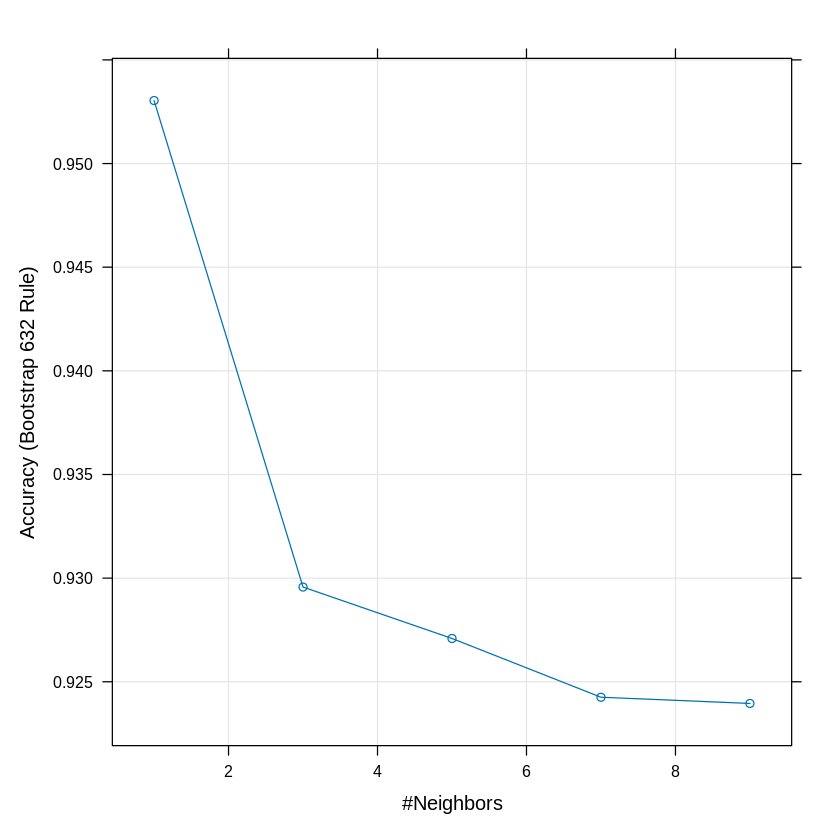

In [74]:
KNNmodel.tuned = train(vote.r[,1:16], vote.r$Class,
                       method="knn",
                       trControl = trainControl(method="boot632"),
                       tuneGrid = expand.grid(k = c(1,3,5,7,9)))
KNNmodel.tuned
plot(KNNmodel.tuned)

Since k = 1 looks the best, the 0.632-bootstrap is suspect. Why? Let's try cross-validation

In [75]:
KNNmodel.tuned = train(vote.r[,1:16], vote.r$Class,
                       method="knn",
                       trControl = trainControl(method="cv"),
                       tuneGrid = expand.grid(k = c(1,3,5,7,9)))
KNNmodel.tuned

k-Nearest Neighbors 

232 samples
 16 predictor
  2 classes: 'democrat', 'republican' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 208, 209, 209, 209, 209, 208, ... 
Resampling results across tuning parameters:

  k  Accuracy   Kappa    
  1  0.9275362  0.8556262
  3  0.9231884  0.8469684
  5  0.9317029  0.8636237
  7  0.9228096  0.8457875
  9  0.9186430  0.8376817

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 5.

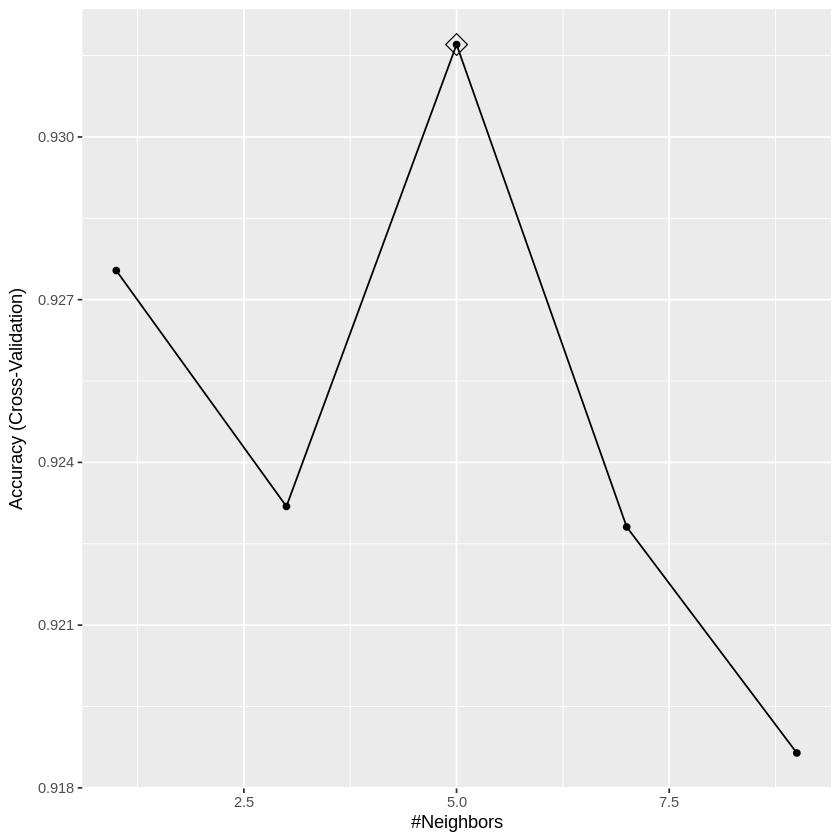

In [76]:
# We can look at the accuracy (default)
ggplot(KNNmodel.tuned,
       metric="Accuracy",
       highlight=TRUE)

Apparently k=1 only looked the best because we were using the 0.632-bootstrap to estimate the error!

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


k-Nearest Neighbors 

232 samples
 16 predictor
  2 classes: 'democrat', 'republican' 

No pre-processing
Resampling: Leave-One-Out Cross-Validation 
Summary of sample sizes: 231, 231, 231, 231, 231, 231, ... 
Resampling results across tuning parameters:

  k  Accuracy   Kappa
  1  0.9137931  0    
  3  0.9181034  0    
  5  0.9267241  0    
  7  0.9267241  0    
  9  0.9181034  0    

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 7.

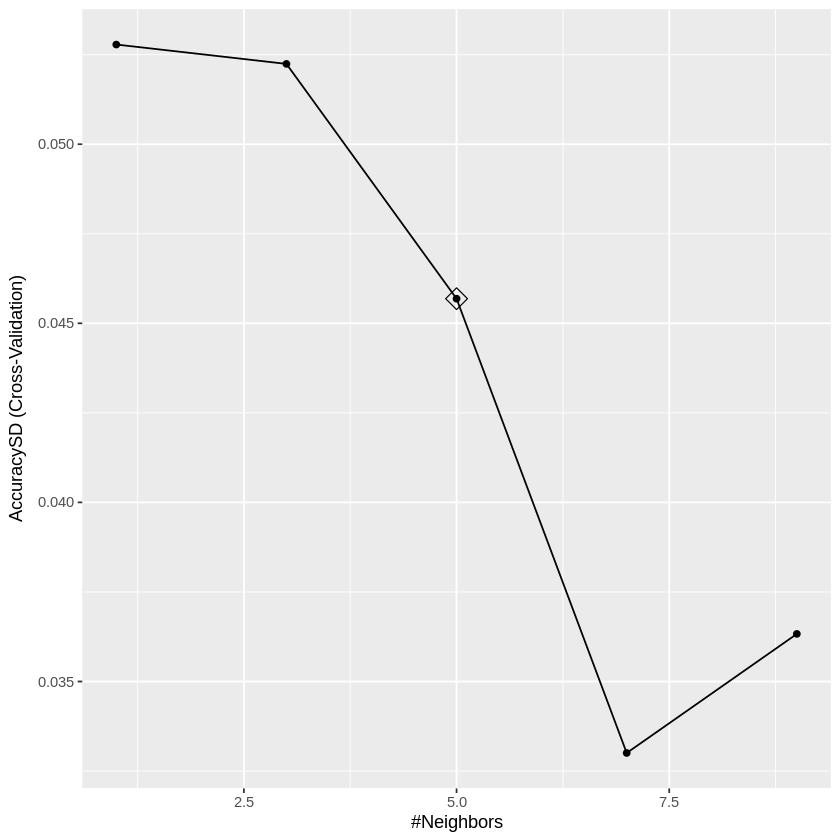

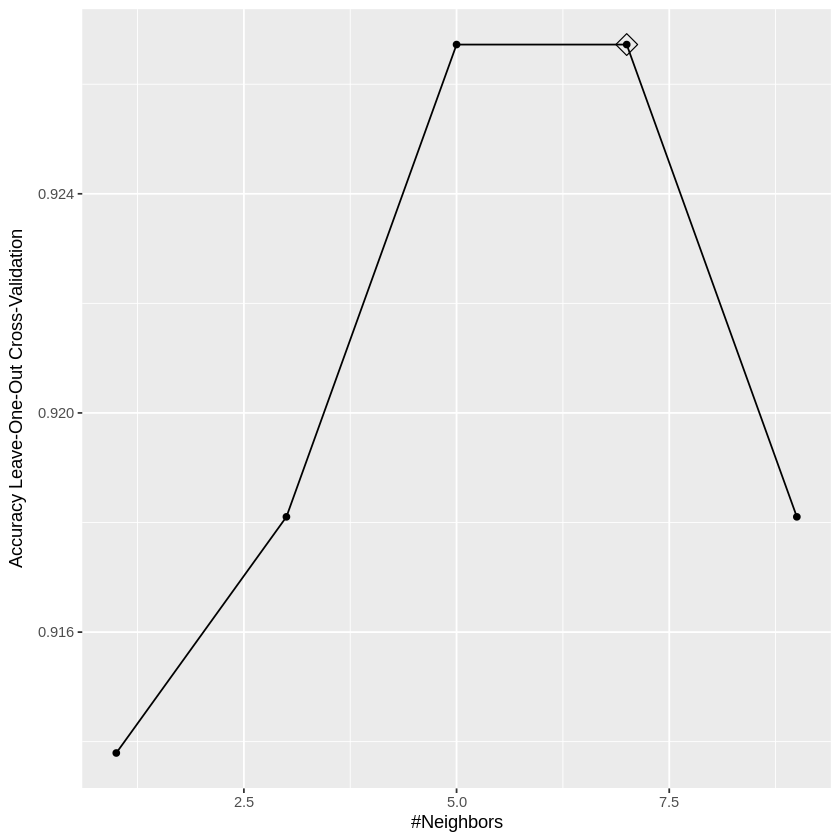

In [77]:
# We can also plot other measures such as the kappa measure (learn
# later), or the stanndard deviation of the accuracy
ggplot(KNNmodel.tuned,
       metric="AccuracySD",
       highlight=TRUE)

#Let's also try LOOCV.
KNNmodel.tuned = train(vote.r[,1:16], vote.r$Class,
                       method="knn",
                       trControl = trainControl(method="loocv"),
                       tuneGrid = expand.grid(k = c(1,3,5,7,9)))
KNNmodel.tuned
ggplot(KNNmodel.tuned,
       metric="Accuracy",
       highlight=TRUE)

 Maybe the default value of k=5 is ok after all?

## **Back to Titanic Data with KNN**

No let's try knn. I'll need to make some modifications to the data, so I'm going to create a copy and then change the copy.

In [78]:
titanic_knn = titanic_train

I want to make all the predictor variables numeric.

Pclass is already a factor with values 1,2,3, so that is easy

In [79]:
titanic_knn$Pclass = as.numeric(titanic_knn$Pclass)

For Sex and Embarked, they are characters, so I'll first change them to factors and then make them numeric.

In [80]:
titanic_knn$Sex = factor(titanic_knn$Sex)
titanic_knn$Sex = as.numeric(titanic_knn$Sex)

titanic_knn$Embarked = factor(titanic_knn$Embarked)
titanic_knn$Embarked = as.numeric(titanic_knn$Embarked)

str(titanic_knn)

'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : Factor w/ 2 levels "0","1": 1 2 2 2 1 1 1 1 2 2 ...
 $ Pclass     : num  3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : chr  "Braund, Mr. Owen Harris" "Cumings, Mrs. John Bradley (Florence Briggs Thayer)" "Heikkinen, Miss. Laina" "Futrelle, Mrs. Jacques Heath (Lily May Peel)" ...
 $ Sex        : num  2 1 1 1 2 2 2 2 1 1 ...
 $ Age        : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : chr  "A/5 21171" "PC 17599" "STON/O2. 3101282" "113803" ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : chr  "" "C85" "" "C123" ...
 $ Embarked   : num  4 2 4 4 4 3 4 4 4 2 ...


Are you happy with how we dealt with non-numeric variables?

Are there missing values?

In [81]:
sum(is.na(titanic_knn))

[1] 177

Yes, we should delete those row. Number of rows we start out with:

In [82]:
length(titanic_knn$PassengerId)

[1] 891

Delete the rows with missing values:

[1] 714

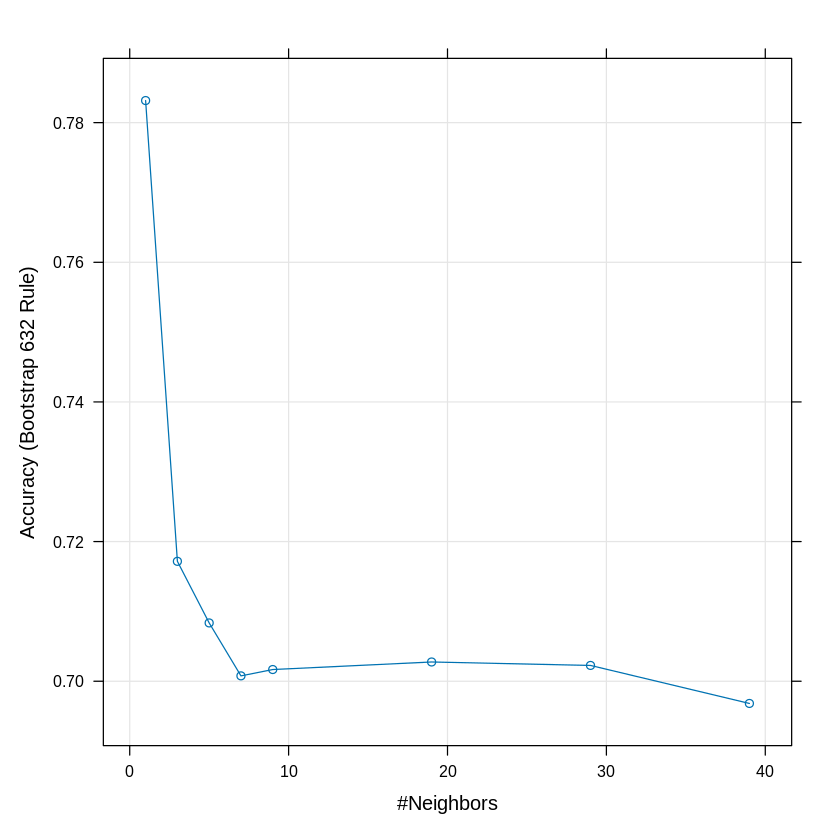

In [84]:
titanic_knn = na.omit(titanic_knn)
length(titanic_knn$PassengerId)


KNNmodel.tuned = train(titanic_knn[,predictors], titanic_knn$Survived,
                       method="knn",
                       trControl = trainControl(method="boot632"),
                       tuneGrid = expand.grid(k = c(1,3,5,7,9,19,29,39)))
plot(KNNmodel.tuned)


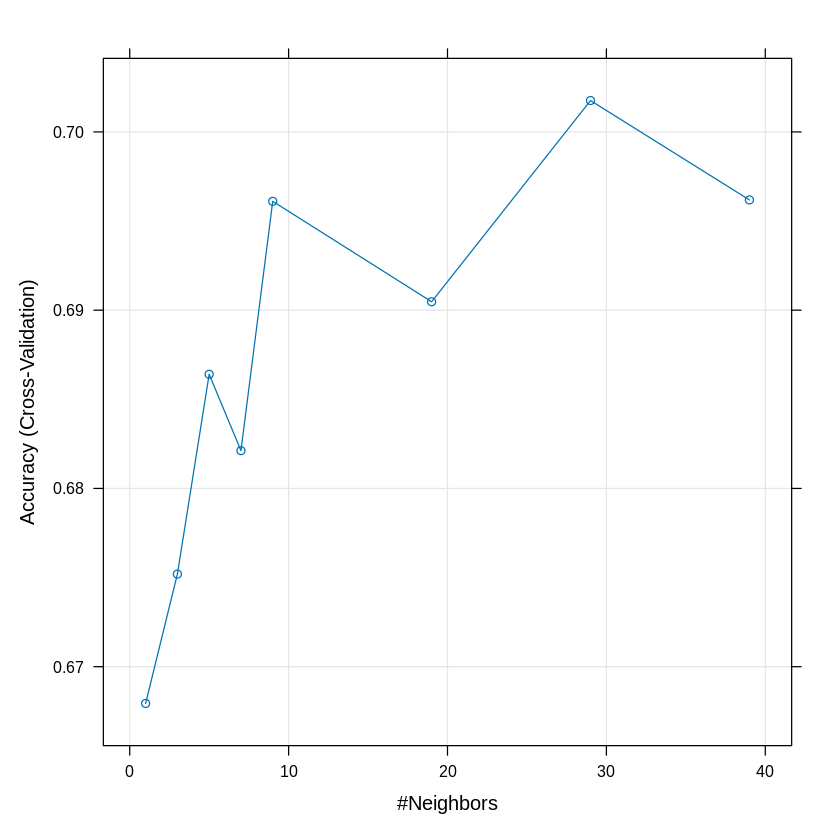

In [85]:
KNNmodel.tuned = train(titanic_knn[,predictors], titanic_knn$Survived,
                       method="knn",
                       trControl = trainControl(method="cv"),
                       tuneGrid = expand.grid(k = c(1,3,5,7,9,19,29,39)))
plot(KNNmodel.tuned)

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


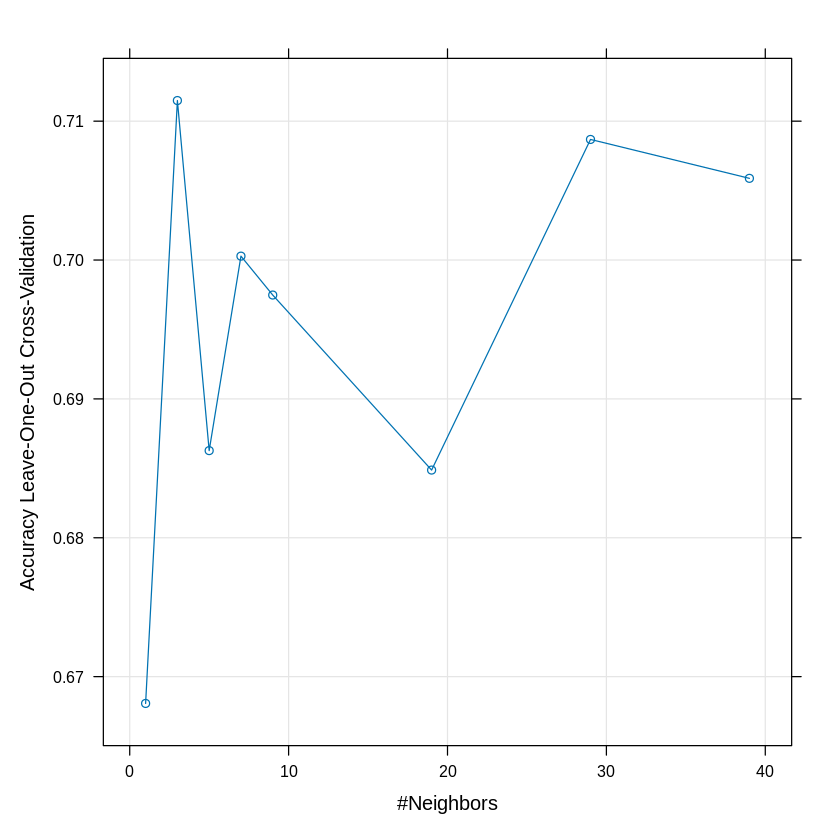

In [86]:
KNNmodel.tuned = train(titanic_knn[,predictors], titanic_knn$Survived,
                       method="knn",
                       trControl = trainControl(method="loocv"),
                       tuneGrid = expand.grid(k = c(1,3,5,7,9,19,29,39)))
plot(KNNmodel.tuned)

In [87]:
# Take a look at what the models are doing for k=1, k=3 and k=39
KNNmodel.1 = knn3(as.formula(paste("Survived~",
                                   paste(predictors, collapse= "+"))),
                  data=titanic_knn,
                  k=1)
KNNmodel.3 = knn3(as.formula(paste("Survived~",
                                   paste(predictors, collapse= "+"))),
                  data=titanic_knn,
                  k=3)
KNNmodel.39 = knn3(as.formula(paste("Survived~",
                                   paste(predictors, collapse= "+"))),
                  data=titanic_knn,
                  k=39)

table(titanic_knn$Survived,
      predict(KNNmodel.1,titanic_knn,type="class"))
table(titanic_knn$Survived,
      predict(KNNmodel.3,titanic_knn,type="class"))
table(titanic_knn$Survived,
      predict(KNNmodel.39,titanic_knn,type="class"))

   
      0   1
  0 421   3
  1   6 284

   
      0   1
  0 375  49
  1  81 209

   
      0   1
  0 359  65
  1 141 149

What do you observe from the confusion matrices?